In [1]:
import pandas as pd
import numpy as np
import zipfile
import requests
from io import BytesIO

In [79]:
url_data = "https://datosabiertos.salud.gob.mx/gobmx/salud/datos_abiertos/efe/datos_abiertos_efe.zip"

response = requests.get(url_data)
zip_file = zipfile.ZipFile(BytesIO(response.content))

# Ver archivos dentro del zip
zip_file.namelist()

['efes_abierto_13.csv', '__MACOSX/._efes_abierto_13.csv']

In [115]:
df = pd.read_csv(zip_file.open('efes_abierto_13.csv'), encoding='latin-1')
df.head()

,FECHA_ACTUALIZACION,ID_REGISTRO,EDAD_ANOS,EDAD_MESES,EDAD_DIAS,SEXO,HABLA_LENGUA_INDIG,INDIGENA,ENTIDAD_UM_NOTIF,MUNICIPIO_UM_NOTIF,...,INSTITUCION_NOTIF,VACUNACION,EXANTEMA,FIEBRE,COMPLICACIONES,DEFUNCION,DIAGNOSTICO,CRITERIO_DIAGNOSTICO,FECHA_DIAGNOSTICO,ORIGEN_CASO
0,06/04/2026,48913,4,10,28,2,2,2,2,3,...,4,1,1,1,1,2,3,2,26/01/2026,5.0
1,06/04/2026,48920,15,11,21,2,2,2,14,70,...,4,2,1,1,2,2,1,2,29/01/2026,2.0
2,06/04/2026,48958,6,6,19,1,2,2,14,98,...,4,2,1,1,2,2,1,2,29/01/2026,2.0
3,06/04/2026,48962,7,5,2,2,1,1,25,12,...,5,2,1,1,2,2,1,2,22/01/2026,1.0
4,06/04/2026,48968,16,9,12,1,1,1,22,14,...,12,2,1,1,2,2,1,2,12/02/2026,4.0


In [116]:
url_dict = "https://datosabiertos.salud.gob.mx/gobmx/salud/datos_abiertos/efe/diccionario_datos_efe.zip"

response_dict = requests.get(url_dict)
zip_dict = zipfile.ZipFile(BytesIO(response_dict.content))

zip_dict.namelist()

['20201123_Catálogos_EFEs.xlsx', '20201123_Descriptores_EFEs.xlsx']

In [117]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [118]:
catalogos = pd.read_excel(zip_dict.open('20201123_Catálogos_EFEs.xlsx'), sheet_name=None)

# Ver nombres de hojas
catalogos.keys()

dict_keys(['CATÁLOGO INSTITUCIÓN', 'CATÁLOGO ORIGEN_CASO', 'CATÁLOGO CRITERIO_DIAGNOSTICO', 'CATÁLOGO DIAGNOSTICO', 'CATÁLOGO MUNICIPIOS', 'CATÁLOGO ENTIDADES', 'Catálogo SEXO', 'Catálogo SI_NO'])

In [119]:
def crear_diccionario(df_catalogo):
    df_catalogo = df_catalogo.dropna()
    
    # Tomar solo primeras dos columnas
    df_catalogo = df_catalogo.iloc[:, :2]
    
    # Renombrar por claridad
    df_catalogo.columns = ['codigo', 'descripcion']
    
    return dict(zip(df_catalogo['codigo'], df_catalogo['descripcion']))

In [120]:
diccionarios = {}

for nombre_hoja, df_cat in catalogos.items():
    try:
        diccionarios[nombre_hoja] = crear_diccionario(df_cat)
    except:
        pass

In [121]:
diccionarios

{'CATÁLOGO INSTITUCIÓN': {1: 'CRUZ ROJA',
  2: 'DIF',
  3: 'ESTATAL',
  4: 'IMSS',
  5: 'IMSS-BIENESTAR',
  6: 'ISSSTE',
  7: 'MUNICIPAL',
  8: 'PEMEX',
  9: 'PRIVADA',
  10: 'SEDENA',
  11: 'SEMAR',
  12: 'SSA',
  13: 'UNIVERSITARIO',
  99: 'NO ESPECIFICADO'},
 'CATÁLOGO ORIGEN_CASO': {1: 'IMPORTADO',
  2: 'RELACIONADO A IMPORTACIÓN',
  3: 'AUTÓCTONO',
  4: 'FUENTE DESCONOCIDA',
  5: 'NO APLICA'},
 'CATÁLOGO CRITERIO_DIAGNOSTICO': {0: 'SIN DIAGNÓSTICO ',
  1: 'CLÍNICO-EPIDEMIOLÓGICO',
  2: 'LABORATORIO'},
 'CATÁLOGO DIAGNOSTICO': {0: 'SIN DIAGNÓSTICO',
  1: 'SARAMPIÓN',
  2: 'RUBÉOLA',
  3: 'DESCARTADO'},
 'CATÁLOGO MUNICIPIOS': {1: 'APOZOL',
  2: 'APULCO',
  3: 'ATOLINGA',
  4: 'BENITO JUÁREZ',
  5: 'CALERA',
  6: 'CAÑITAS DE FELIPE PESCADOR',
  7: 'CONCEPCIÓN DEL ORO',
  8: 'CUAUHTÉMOC',
  9: 'CHALCHIHUITES',
  10: 'FRESNILLO',
  11: 'TRINIDAD GARCÍA DE LA CADENA',
  999: 'NO ESPECIFICADO',
  12: 'GENARO CODINA',
  13: 'GENERAL ENRIQUE ESTRADA',
  14: 'GENERAL FRANCISCO R. MURGUÍA',

In [122]:
mapa_variables = {
    'SEXO': 'Catálogo SEXO',
    'HABLA_LENGUA_INDIG': 'Catálogo SI_NO',
    'INDIGENA': 'Catálogo SI_NO',
    'ENTIDAD_UM_NOTIF': 'CATÁLOGO ENTIDADES',
    'MUNICIPIO_UM_NOTIF': 'CATÁLOGO MUNICIPIOS',
    'ENTIDAD_RES': 'CATÁLOGO ENTIDADES',
    'MUNICIPIO_RES': 'CATÁLOGO MUNICIPIOS',
    'INSTITUCION_NOTIF': 'CATÁLOGO INSTITUCIÓN',
    'VACUNACION': 'Catálogo SI_NO',
    'EXANTEMA': 'Catálogo SI_NO',
    'FIEBRE': 'Catálogo SI_NO',
    'COMPLICACIONES': 'Catálogo SI_NO',
    'DEFUNCION': 'Catálogo SI_NO',
    'DIAGNOSTICO': 'CATÁLOGO DIAGNOSTICO',
    'CRITERIO_DIAGNOSTICO': 'CATÁLOGO CRITERIO_DIAGNOSTICO',
    'ORIGEN_CASO': 'CATÁLOGO ORIGEN_CASO'
}

In [123]:
for columna, nombre_catalogo in mapa_variables.items():
    
    if columna in df.columns and nombre_catalogo in diccionarios:
        
        df[columna] = df[columna].map(diccionarios[nombre_catalogo])

In [124]:
df[['EDAD_ANOS', 'SEXO', 'DEFUNCION', 'DIAGNOSTICO']].head()

,EDAD_ANOS,SEXO,DEFUNCION,DIAGNOSTICO
0,4,HOMBRE,NO,DESCARTADO
1,15,HOMBRE,NO,SARAMPIÓN
2,6,MUJER,NO,SARAMPIÓN
3,7,HOMBRE,NO,SARAMPIÓN
4,16,MUJER,NO,SARAMPIÓN


In [125]:
df['FECHA_ACTUALIZACION'] = pd.to_datetime(df['FECHA_ACTUALIZACION'], dayfirst=True, errors='coerce')
df['FECHA_DIAGNOSTICO'] = pd.to_datetime(df['FECHA_DIAGNOSTICO'], dayfirst=True, errors='coerce')

In [92]:
#df['EDAD_TOTAL'] = df['EDAD_ANOS'] + df['EDAD_MESES']/12 + df['EDAD_DIAS']/365

In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21437 entries, 0 to 21436
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   FECHA_ACTUALIZACION   21437 non-null  datetime64[ns]
 1   ID_REGISTRO           21437 non-null  int64         
 2   EDAD_ANOS             21437 non-null  int64         
 3   EDAD_MESES            21437 non-null  int64         
 4   EDAD_DIAS             21437 non-null  int64         
 5   SEXO                  21437 non-null  object        
 6   HABLA_LENGUA_INDIG    21437 non-null  object        
 7   INDIGENA              21437 non-null  object        
 8   ENTIDAD_UM_NOTIF      21437 non-null  object        
 9   MUNICIPIO_UM_NOTIF    21437 non-null  object        
 10  ENTIDAD_RES           21436 non-null  object        
 11  MUNICIPIO_RES         21437 non-null  object        
 12  INSTITUCION_NOTIF     17255 non-null  object        
 13  VACUNACION      

In [127]:
df.isnull().sum().sort_values(ascending=False)

FECHA_DIAGNOSTICO       4271
INSTITUCION_NOTIF       4182
ORIGEN_CASO              193
ENTIDAD_RES                1
FECHA_ACTUALIZACION        0
ID_REGISTRO                0
SEXO                       0
EDAD_DIAS                  0
EDAD_MESES                 0
EDAD_ANOS                  0
MUNICIPIO_UM_NOTIF         0
ENTIDAD_UM_NOTIF           0
HABLA_LENGUA_INDIG         0
INDIGENA                   0
VACUNACION                 0
MUNICIPIO_RES              0
EXANTEMA                   0
FIEBRE                     0
DEFUNCION                  0
COMPLICACIONES             0
CRITERIO_DIAGNOSTICO       0
DIAGNOSTICO                0
dtype: int64

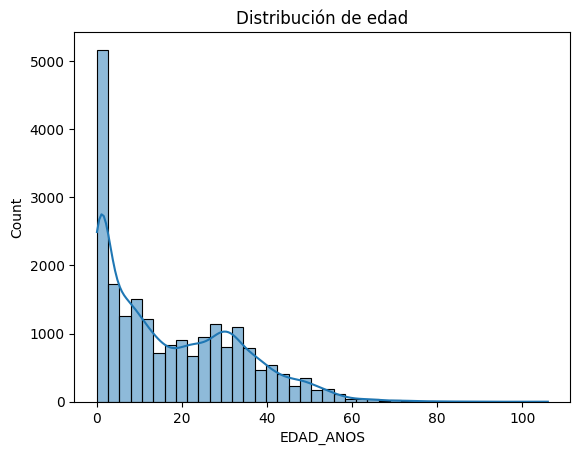

In [128]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['EDAD_ANOS'], bins=40, kde=True)
plt.title("Distribución de edad")
plt.show()

In [129]:
df['SEXO'].value_counts(normalize=True)

SEXO
HOMBRE    0.521715
MUJER     0.478285
Name: proportion, dtype: float64

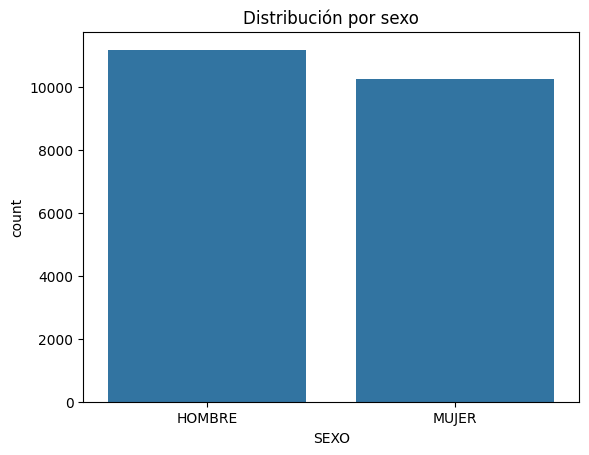

In [130]:
sns.countplot(x='SEXO', data=df)
plt.title("Distribución por sexo")
plt.show()

FIEBRE
SI     1.0
Name: proportion, dtype: float64


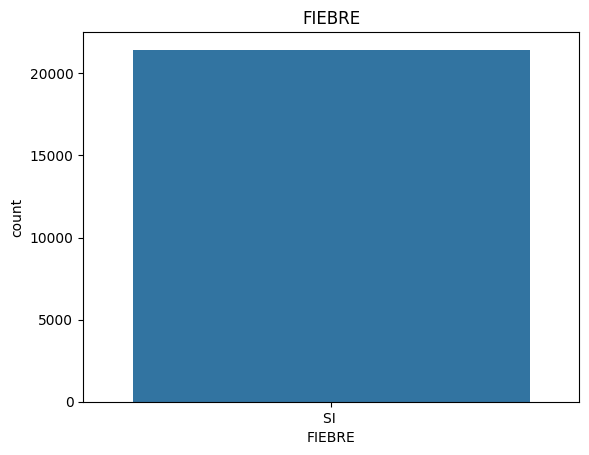

EXANTEMA
SI     1.0
Name: proportion, dtype: float64


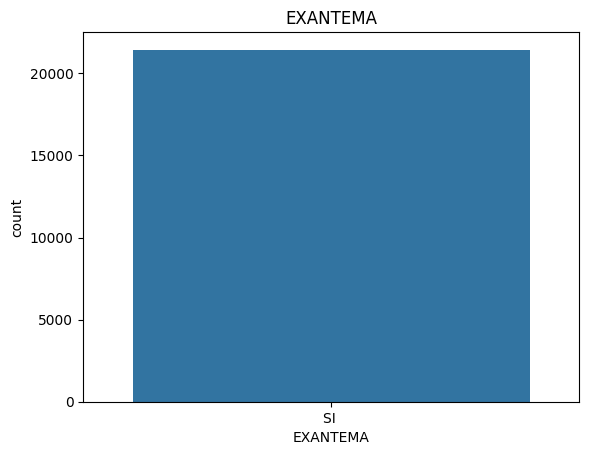

COMPLICACIONES
NO     0.952139
SI     0.047861
Name: proportion, dtype: float64


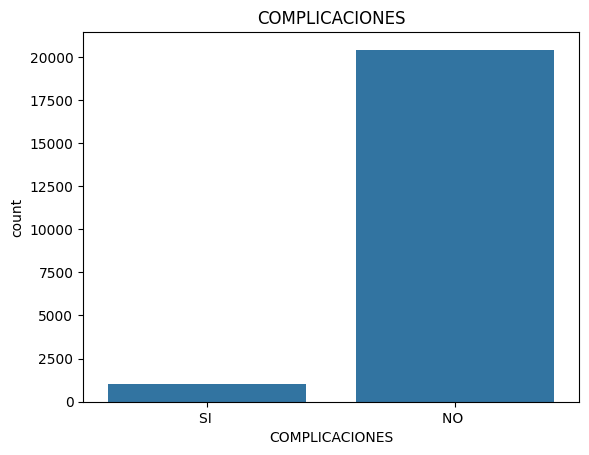

In [131]:
cols = ['FIEBRE', 'EXANTEMA', 'COMPLICACIONES']

for col in cols:
    print(df[col].value_counts(normalize=True))
    sns.countplot(x=col, data=df)
    plt.title(col)
    plt.show()

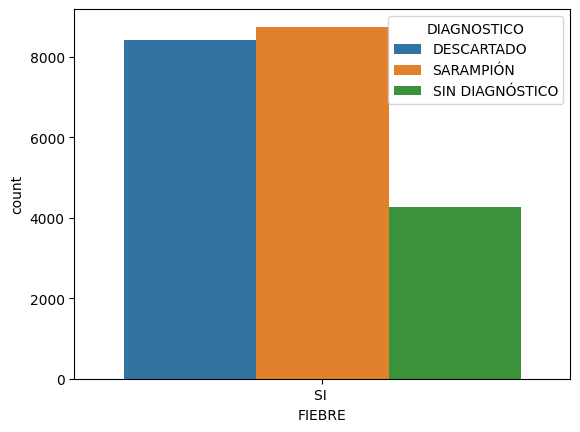

In [132]:
sns.countplot(x='FIEBRE', hue='DIAGNOSTICO', data=df)
plt.show()

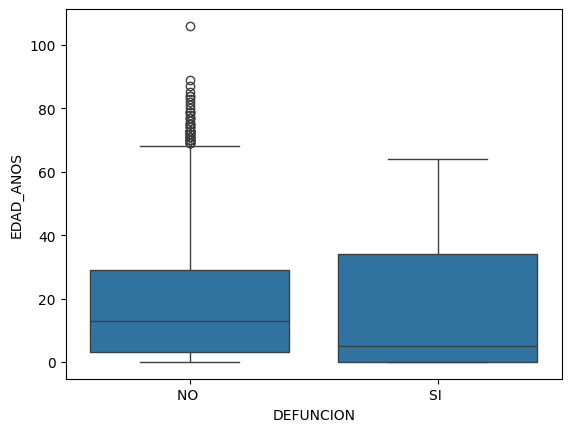

In [133]:
sns.boxplot(x='DEFUNCION', y='EDAD_ANOS', data=df)
plt.show()

In [134]:
pd.crosstab(df['SEXO'], df['DEFUNCION'], normalize='index')

DEFUNCION,NO,SI
SEXO,,
HOMBRE,0.998838,0.001162
MUJER,0.998830,0.001170


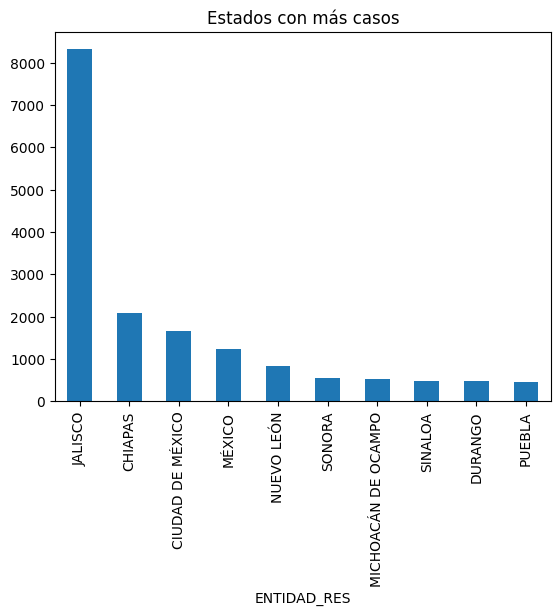

In [135]:
top_states = df['ENTIDAD_RES'].value_counts().head(10)

top_states.plot(kind='bar')
plt.title("Estados con más casos")
plt.show()

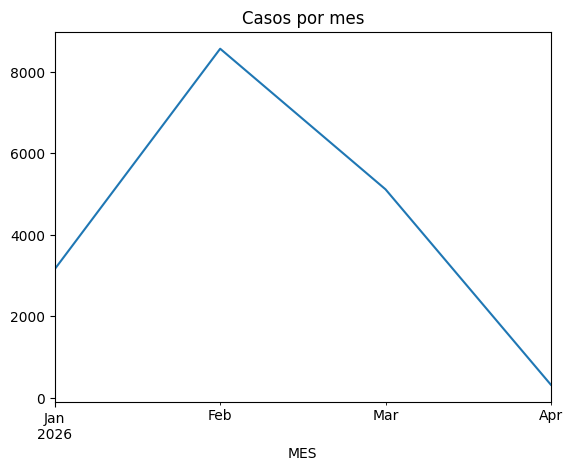

In [136]:
df['MES'] = df['FECHA_DIAGNOSTICO'].dt.to_period('M')

df.groupby('MES').size().plot()
plt.title("Casos por mes")
plt.show()

In [137]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# -------------------------------
# 1. Selección de variables
# -------------------------------
features = ['EDAD_ANOS', 'FIEBRE', 'COMPLICACIONES', 'VACUNACION']
target = 'DEFUNCION'

# Copia (NO tocamos df original)
data = df[features + [target]].copy()

print("Filas iniciales:", data.shape[0])

# -------------------------------
# 2. Función robusta de binarización
# -------------------------------
def binarizar(col):
    # Convertir a string para evitar problemas mixtos
    col = col.astype(str).str.strip().str.upper()
    
    # Mapeo robusto
    return col.replace({
        'SI': 1,
        'SÍ': 1,
        '1': 1,
        
        'NO': 0,
        '2': 0,
        
        'NAN': np.nan,
        '': np.nan,
        'NO APLICA': np.nan,
        'SE IGNORA': np.nan,
        '98': np.nan,
        '99': np.nan
    })

# -------------------------------
# 3. Aplicar binarización
# -------------------------------
for col in ['FIEBRE', 'COMPLICACIONES', 'VACUNACION', 'DEFUNCION']:
    data[col] = binarizar(data[col])

# -------------------------------
# 4. Convertir edad a numérica
# -------------------------------
data['EDAD_ANOS'] = pd.to_numeric(data['EDAD_ANOS'], errors='coerce')

# -------------------------------
# 5. Limpieza FINAL (consistente)
# -------------------------------
data = data.dropna()

print("Filas después de limpieza:", data.shape[0])

# ⚠️ Validación crítica
if data.shape[0] == 0:
    raise ValueError("Te quedaste sin datos. Revisa los valores originales con df[col].unique()")

# -------------------------------
# 6. Separar X e y
# -------------------------------
X = data[features]
y = data[target]

# -------------------------------
# 7. Ver distribución del target
# -------------------------------
print("\nDistribución DEFUNCION:")
print(y.value_counts(normalize=True))

# -------------------------------
# 8. Train/Test split seguro
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y if len(y.unique()) > 1 else None
)

# -------------------------------
# 9. Modelo
# -------------------------------
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'  # importante en datos de salud
)

model.fit(X_train, y_train)

# -------------------------------
# 10. Evaluación
# -------------------------------
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

print("\nROC AUC:")
print(roc_auc_score(y_test, y_prob))

# -------------------------------
# 11. Interpretación
# -------------------------------
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model.coef_[0],
    'Odds Ratio': np.exp(model.coef_[0])
})

print("\nCoeficientes:")
print(coef_df)

Filas iniciales: 21437


C:\Users\victo\AppData\Local\Temp\ipykernel_8920\3085347383.py:26: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace({
C:\Users\victo\AppData\Local\Temp\ipykernel_8920\3085347383.py:26: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace({
C:\Users\victo\AppData\Local\Temp\ipykernel_8920\3085347383.py:26: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the 

Filas después de limpieza: 21437

Distribución DEFUNCION:
DEFUNCION
0    0.998834
1    0.001166
Name: proportion, dtype: float64

Matriz de confusión:
[[4096  187]
 [   2    3]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      4283
           1       0.02      0.60      0.03         5

    accuracy                           0.96      4288
   macro avg       0.51      0.78      0.50      4288
weighted avg       1.00      0.96      0.98      4288


ROC AUC:
0.830422600980621

Coeficientes:
         Variable  Coeficiente  Odds Ratio
0       EDAD_ANOS     0.006005    1.006024
1          FIEBRE    -0.520567    0.594183
2  COMPLICACIONES     3.787975   44.166853
3      VACUNACION    -0.872191    0.418034


In [138]:
print("\n" + "="*50)
print("📊 RESUMEN DEL MODELO")
print("="*50)

print(f"\nTotal de observaciones usadas: {len(y)}")

print("\nDistribución de DEFUNCION:")
print(y.value_counts().rename({0: 'No', 1: 'Sí'}))


📊 RESUMEN DEL MODELO

Total de observaciones usadas: 21437

Distribución de DEFUNCION:
DEFUNCION
No    21412
Sí       25
Name: count, dtype: int64


In [139]:
print("\n" + "="*50)
print("📈 DESEMPEÑO DEL MODELO")
print("="*50)

print("\nMatriz de confusión:")
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=['Real: No', 'Real: Sí'],
    columns=['Pred: No', 'Pred: Sí']
)
print(cm_df)


📈 DESEMPEÑO DEL MODELO

Matriz de confusión:
          Pred: No  Pred: Sí
Real: No      4096       187
Real: Sí         2         3


In [140]:
tn, fp, fn, tp = cm.ravel()

print("\nInterpretación:")
print(f"- Verdaderos negativos (No predicho correctamente): {tn}")
print(f"- Falsos positivos (predijo muerte pero no ocurrió): {fp}")
print(f"- Falsos negativos (NO detectó muerte real ⚠️): {fn}")
print(f"- Verdaderos positivos (detectó muerte correctamente): {tp}")


Interpretación:
- Verdaderos negativos (No predicho correctamente): 4096
- Falsos positivos (predijo muerte pero no ocurrió): 187
- Falsos negativos (NO detectó muerte real ⚠️): 2
- Verdaderos positivos (detectó muerte correctamente): 3


In [141]:
report = classification_report(y_test, y_pred, output_dict=True)

print("\nMétricas clave:")

print(f"- Precisión (cuando predice muerte, acierta): {report['1']['precision']:.3f}")
print(f"- Recall (detecta muertes reales): {report['1']['recall']:.3f}")
print(f"- F1-score (balance): {report['1']['f1-score']:.3f}")

roc = roc_auc_score(y_test, y_prob)
print(f"- ROC AUC (calidad general del modelo): {roc:.3f}")


Métricas clave:
- Precisión (cuando predice muerte, acierta): 0.016
- Recall (detecta muertes reales): 0.600
- F1-score (balance): 0.031
- ROC AUC (calidad general del modelo): 0.830


In [142]:
print("\n" + "="*50)
print("🧠 INTERPRETACIÓN DEL MODELO")
print("="*50)

if roc > 0.8:
    print("El modelo tiene MUY buena capacidad de discriminación.")
elif roc > 0.7:
    print("El modelo tiene buena capacidad de discriminación.")
else:
    print("El modelo tiene capacidad limitada para distinguir casos.")

if report['1']['recall'] < 0.5:
    print("⚠️ El modelo está fallando en detectar muertes (recall bajo).")


🧠 INTERPRETACIÓN DEL MODELO
El modelo tiene MUY buena capacidad de discriminación.


In [143]:
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model.coef_[0],
    'Odds Ratio': np.exp(model.coef_[0])
})

coef_df = coef_df.sort_values(by='Odds Ratio', ascending=False)

print("\n" + "="*50)
print("📌 FACTORES DE RIESGO (interpretación)")
print("="*50)

for _, row in coef_df.iterrows():
    var = row['Variable']
    or_val = row['Odds Ratio']
    
    if or_val > 1:
        print(f"🔺 {var} aumenta el riesgo de defunción en {or_val:.2f} veces")
    else:
        print(f"🔻 {var} reduce el riesgo de defunción (OR = {or_val:.2f})")


📌 FACTORES DE RIESGO (interpretación)
🔺 COMPLICACIONES aumenta el riesgo de defunción en 44.17 veces
🔺 EDAD_ANOS aumenta el riesgo de defunción en 1.01 veces
🔻 FIEBRE reduce el riesgo de defunción (OR = 0.59)
🔻 VACUNACION reduce el riesgo de defunción (OR = 0.42)


In [144]:
print("\n" + "="*50)
print("📄 CONCLUSIONES")
print("="*50)

print("Este modelo estima la probabilidad de defunción en función de edad, síntomas y vacunación.")

print("\nHallazgos clave:")

top_risk = coef_df.iloc[0]
print(f"- El factor más asociado al riesgo es: {top_risk['Variable']}")

protective = coef_df[coef_df['Odds Ratio'] < 1]
if not protective.empty:
    print(f"- Factor protector identificado: {protective.iloc[0]['Variable']}")


📄 CONCLUSIONES
Este modelo estima la probabilidad de defunción en función de edad, síntomas y vacunación.

Hallazgos clave:
- El factor más asociado al riesgo es: COMPLICACIONES
- Factor protector identificado: FIEBRE


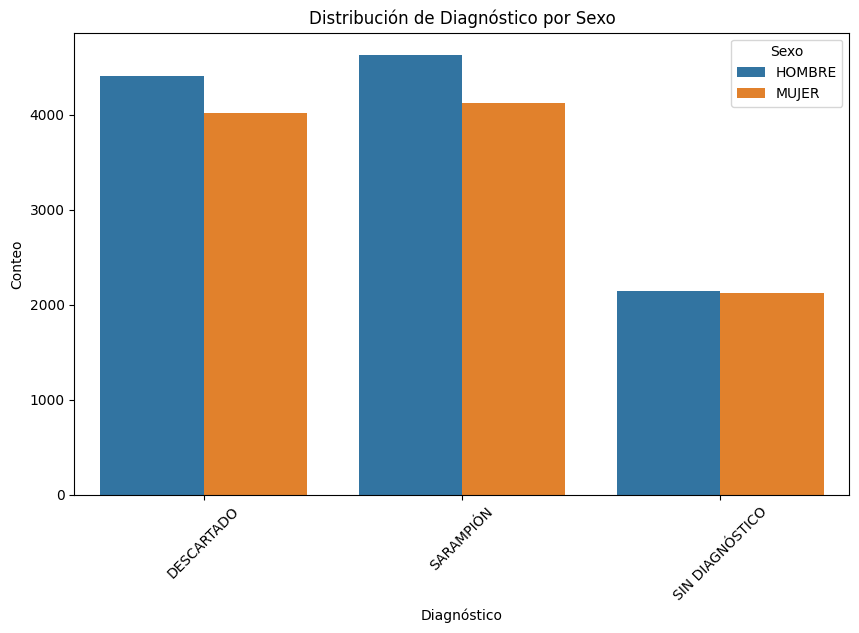

In [147]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='DIAGNOSTICO',
    hue='SEXO'
)

plt.title("Distribución de Diagnóstico por Sexo")
plt.xlabel("Diagnóstico")
plt.ylabel("Conteo")
plt.xticks(rotation=45)
plt.legend(title="Sexo")

plt.show()

In [150]:
import plotly.graph_objects as go

# Limpiar columna (CLAVE 🔥)
temp = df['DEFUNCION'].astype(str).str.strip().str.upper()

# Contar valores correctamente
muertes = (temp == 'SÍ').sum() + (temp == 'SI').sum()
sobreviven = (temp == 'NO').sum()

# Labels
labels = ['Casos de defunción', 'Casos sobrevivientes']
values = [muertes, sobreviven]

# Gráfica
fig = go.Figure(data=[go.Pie(labels=labels, values=values)])

fig.update_layout(title="Distribución de defunciones")

fig.show()

In [151]:
import pandas as pd
import plotly.graph_objects as go

# Copia de seguridad
df_ts = df.copy()

# Fechas
df_ts['FECHA_DIAGNOSTICO'] = pd.to_datetime(df_ts['FECHA_DIAGNOSTICO'], errors='coerce')

# Ordenar
df_ts = df_ts.sort_values('FECHA_DIAGNOSTICO')

In [152]:
daily = df_ts.groupby('FECHA_DIAGNOSTICO').agg(
    Confirmados=('DIAGNOSTICO', lambda x: (x.astype(str).str.upper().str.contains('SAR')).sum()),
    Muertes=('DEFUNCION', lambda x: (x.astype(str).str.upper().str.contains('SÍ|SI')).sum()),
    Casos_Totales=('DIAGNOSTICO', 'count')
).reset_index()

In [153]:
daily['Confirmados'] = daily['Confirmados'].cumsum()
daily['Muertes'] = daily['Muertes'].cumsum()
daily['Casos_Totales'] = daily['Casos_Totales'].cumsum()

In [156]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=daily['FECHA_DIAGNOSTICO'],
    y=daily['Casos_Totales'],
    mode='lines+markers',
    name='Casos Totales EFE'
))

fig.add_trace(go.Scatter(
    x=daily['FECHA_DIAGNOSTICO'],
    y=daily['Confirmados'],
    mode='lines+markers',
    name='Casos Confirmados (Sarampión)'
))

fig.add_trace(go.Scatter(
    x=daily['FECHA_DIAGNOSTICO'],
    y=daily['Muertes'],
    mode='lines+markers',
    name='Muertes'
))

fig.update_layout(
    title="Evolución acumulada de casos (escala logarítmica)",
    xaxis_title="Fecha",
    yaxis_title="Casos acumulados (log)",
    yaxis_type="log"
)

fig.show()

In [158]:
pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 524.3 kB/s eta 0:00:18
   -- ------------------------------------- 0.5/9.6 MB 524.3 kB/s eta 0:00:18
   -- ------------------------------------- 0.5/9.6 MB 524.3 kB/s eta 0:00:18
   -- ------------------------------------- 0.5/9.6 MB 524.3 kB/s eta 0:00:18
   -- ------------------------------------- 0.5/9.6 MB 524.3 kB/s eta 0:00:18
   --- ------------------------------------ 0.8/9.6 MB 353.3 kB/s eta 0:00:25
   --- ------------------------------------ 0.8/9.6 MB 353.3 kB/s eta 0:00:25
   --- ------------------------------------ 0.8/9.6 MB 353.3 kB/s eta 0:00:25
   ---- -----------------------


[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Asegurar orden temporal
daily = daily.sort_values('FECHA_DIAGNOSTICO')

# Índice temporal
daily = daily.set_index('FECHA_DIAGNOSTICO')

In [160]:
def arima_forecast(series, steps=30, order=(2,1,2)):
    model = ARIMA(series, order=order)
    model_fit = model.fit()
    
    forecast = model_fit.forecast(steps=steps)
    
    return model_fit, forecast

In [161]:
steps = 30  # horizonte de predicción

model_casos, fc_casos = arima_forecast(daily['Casos_Totales'], steps)
model_conf, fc_conf = arima_forecast(daily['Confirmados'], steps)
model_muertes, fc_muertes = arima_forecast(daily['Muertes'], steps)

c:\Users\victo\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\victo\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\victo\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\victo\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting au

In [162]:
future_index = pd.date_range(
    start=daily.index[-1],
    periods=steps+1,
    freq='D'
)[1:]

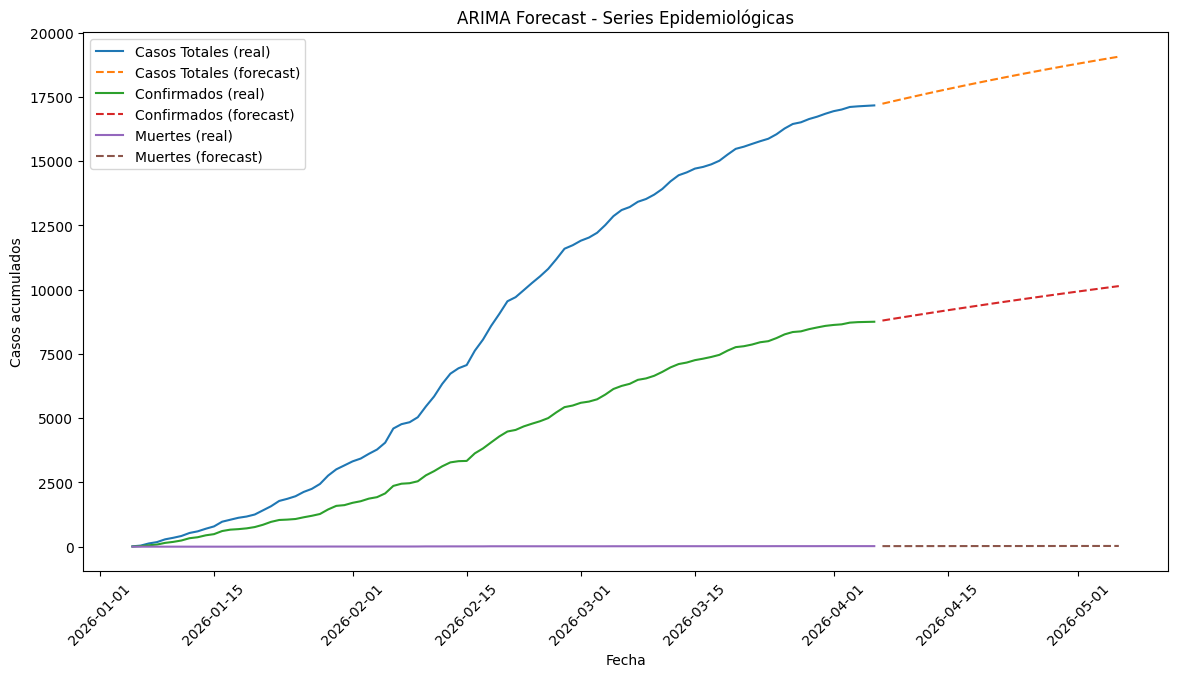

In [163]:
plt.figure(figsize=(14,7))

# --- Casos totales ---
plt.plot(daily.index, daily['Casos_Totales'], label='Casos Totales (real)')
plt.plot(future_index, fc_casos, '--', label='Casos Totales (forecast)')

# --- Confirmados ---
plt.plot(daily.index, daily['Confirmados'], label='Confirmados (real)')
plt.plot(future_index, fc_conf, '--', label='Confirmados (forecast)')

# --- Muertes ---
plt.plot(daily.index, daily['Muertes'], label='Muertes (real)')
plt.plot(future_index, fc_muertes, '--', label='Muertes (forecast)')

plt.title("ARIMA Forecast - Series Epidemiológicas")
plt.xlabel("Fecha")
plt.ylabel("Casos acumulados")
plt.legend()
plt.xticks(rotation=45)

plt.show()

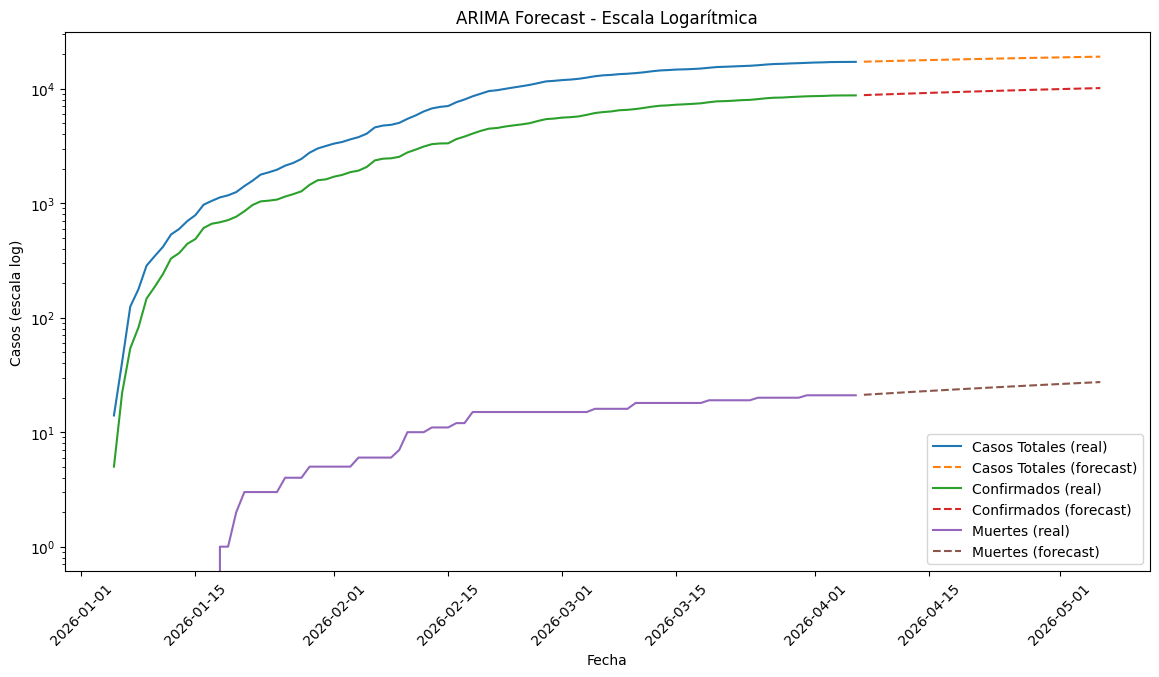

In [164]:
plt.figure(figsize=(14,7))

# Casos totales
plt.plot(daily.index, daily['Casos_Totales'], label='Casos Totales (real)')
plt.plot(future_index, fc_casos, '--', label='Casos Totales (forecast)')

# Confirmados
plt.plot(daily.index, daily['Confirmados'], label='Confirmados (real)')
plt.plot(future_index, fc_conf, '--', label='Confirmados (forecast)')

# Muertes
plt.plot(daily.index, daily['Muertes'], label='Muertes (real)')
plt.plot(future_index, fc_muertes, '--', label='Muertes (forecast)')

plt.title("ARIMA Forecast - Escala Logarítmica")
plt.xlabel("Fecha")
plt.ylabel("Casos (escala log)")

plt.yscale('log')  # 🔥 AQUÍ está el cambio clave

plt.legend()
plt.xticks(rotation=45)
plt.show()

In [165]:
import plotly.graph_objects as go

fig = go.Figure()

# ------------------------
# HISTÓRICO
# ------------------------
fig.add_trace(go.Scatter(
    x=daily.index,
    y=daily['Casos_Totales'],
    mode='lines',
    name='Casos Totales (real)'
))

fig.add_trace(go.Scatter(
    x=daily.index,
    y=daily['Confirmados'],
    mode='lines',
    name='Confirmados (real)'
))

fig.add_trace(go.Scatter(
    x=daily.index,
    y=daily['Muertes'],
    mode='lines',
    name='Muertes (real)'
))

# ------------------------
# FORECAST
# ------------------------
fig.add_trace(go.Scatter(
    x=future_index,
    y=fc_casos,
    mode='lines',
    name='Casos Totales (forecast)',
    line=dict(dash='dash')
))

fig.add_trace(go.Scatter(
    x=future_index,
    y=fc_conf,
    mode='lines',
    name='Confirmados (forecast)',
    line=dict(dash='dash')
))

fig.add_trace(go.Scatter(
    x=future_index,
    y=fc_muertes,
    mode='lines',
    name='Muertes (forecast)',
    line=dict(dash='dash')
))

# ------------------------
# LAYOUT (LOG SCALE)
# ------------------------
fig.update_layout(
    title="Evolución y Forecast de Casos (escala logarítmica)",
    xaxis_title="Fecha",
    yaxis_title="Casos acumulados (log)",
    yaxis_type="log"
)

fig.show()